# 🌾 Fertilizer Classification using Agriculture-BERT
**Model**: `recobo/agriculture-bert-uncased`  
**Task**: 10-class text classification on serialized agronomic row data  
**Hardware**: Kaggle P100 GPU  

---
### Pipeline Overview
1. Install & import dependencies  
2. Load & inspect dataset  
3. Label encoding  
4. Train / Val / Test split  
5. Tokenization + PyTorch Dataset  
6. Load Agriculture-BERT for Sequence Classification  
7. Training with Hugging Face `Trainer`  
8. Evaluation & metrics  
9. Inference on new samples  
10. Save fine-tuned model

## Step 1 — Install Dependencies

In [186]:
!pip install -q transformers datasets scikit-learn seaborn matplotlib

## Step 2 — Imports

In [187]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,   # ← classification head, not MLM
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: Tesla P100-PCIE-16GB
VRAM: 17.1 GB


## Step 3 — Load & Inspect Dataset

In [188]:
DATA_PATH = '/kaggle/input/datasets/sami212/feritlizer-human-readable/Fertilizer_Prediction_text_Human_Readable.csv'
# ↑ Update the path to match your Kaggle dataset input folder name

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (3100, 2)


,text,Fertilizer
0,"In this condition, the temperature is 50.17984...",Compost
1,"In this condition, the temperature is 21.63331...",Balanced NPK Fertilizer
2,"In this condition, the temperature is 23.06096...",Water Retaining Fertilizer


In [189]:
print('Columns:', df.columns.tolist())
print('\nNull values:\n', df.isnull().sum())
print('\nClass distribution:')
print(df['Fertilizer'].value_counts())

Columns: ['text', 'Fertilizer']

Null values:
 text          0
Fertilizer    0
dtype: int64

Class distribution:
Fertilizer
DAP                           1054
Water Retaining Fertilizer     675
Compost                        375
Muriate of Potash              326
Lime                           181
Balanced NPK Fertilizer        157
Urea                           154
Organic Fertilizer              95
Gypsum                          52
General Purpose Fertilizer      31
Name: count, dtype: int64


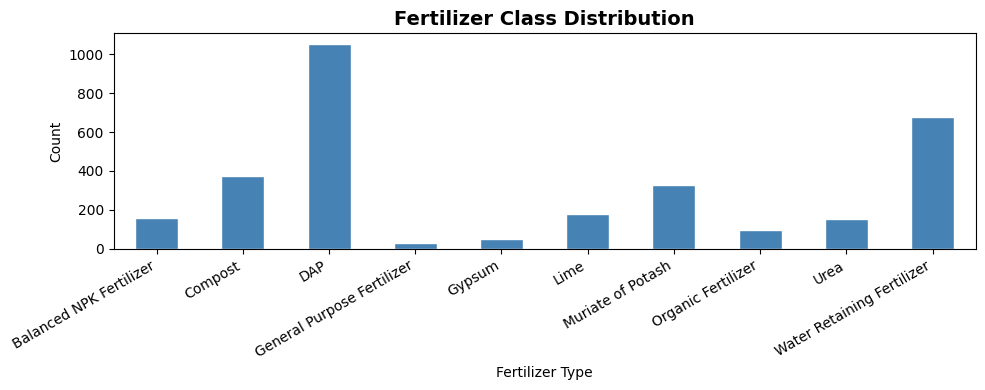

In [190]:
# ── Class distribution bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
df['Fertilizer'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title('Fertilizer Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Fertilizer Type')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Token word count — mean: 64  max: 67  min: 62


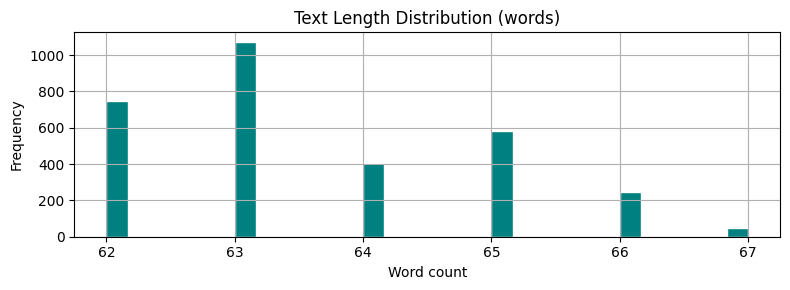

In [191]:
# ── Text length distribution ─────────────────────────────────────────────────
df['text_len'] = df['text'].apply(lambda x: len(x.split()))
print(f"Token word count — mean: {df['text_len'].mean():.0f}  "
      f"max: {df['text_len'].max()}  "
      f"min: {df['text_len'].min()}")

df['text_len'].hist(bins=30, color='teal', edgecolor='white', figsize=(8, 3))
plt.title('Text Length Distribution (words)')
plt.xlabel('Word count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Step 4 — Label Encoding
Mapping per specification:

| ID | Fertilizer |
|----|------------|
| 0 | Balanced NPK Fertilizer |
| 1 | Compost |
| 2 | DAP |
| 3 | General Purpose Fertilizer |
| 4 | Gypsum |
| 5 | Lime |
| 6 | Muriate of Potash |
| 7 | Organic Fertilizer |
| 8 | Urea |
| 9 | Water Retaining Fertilizer |

In [192]:
# ── Manual label map (as specified) ──────────────────────────────────────────
LABEL2ID = {
    'Balanced NPK Fertilizer'  : 0,
    'Compost'                  : 1,
    'DAP'                      : 2,
    'General Purpose Fertilizer': 3,
    'Gypsum'                   : 4,
    'Lime'                     : 5,
    'Muriate of Potash'        : 6,
    'Organic Fertilizer'       : 7,
    'Urea'                     : 8,
    'Water Retaining Fertilizer': 9,
}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = len(LABEL2ID)

df['label'] = df['Fertilizer'].map(LABEL2ID)

# Sanity check — no NaN labels
assert df['label'].isnull().sum() == 0, 'Unmapped label found!'

print('Label mapping verified ✓')
print(df[['Fertilizer', 'label']].drop_duplicates().sort_values('label').to_string(index=False))

Label mapping verified ✓
                Fertilizer  label
   Balanced NPK Fertilizer      0
                   Compost      1
                       DAP      2
General Purpose Fertilizer      3
                    Gypsum      4
                      Lime      5
         Muriate of Potash      6
        Organic Fertilizer      7
                      Urea      8
Water Retaining Fertilizer      9


## Step 5 — Train / Validation / Test Split

In [193]:
from sklearn.model_selection import train_test_split

# First split: keep train the same (70%)
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label']
)

# Now explicitly control test size = 620
test_size_ratio = 620 / len(temp_df)

val_df, test_df = train_test_split(
    temp_df,
    test_size=test_size_ratio,
    random_state=SEED,
    stratify=temp_df['label']
)

# Reset index
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# Print sizes
print(f'Train : {len(train_df):>5} samples')
print(f'Val   : {len(val_df):>5} samples')
print(f'Test  : {len(test_df):>5} samples')

Train :  2170 samples
Val   :   310 samples
Test  :   620 samples


## Step 6 — Tokenizer

In [194]:
MODEL_NAME = 'google-bert/bert-base-uncased'
MAX_LEN    = 256   # covers 99%+ of samples; P100 handles 256 comfortably

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Quick check: how many samples exceed MAX_LEN tokens
sample_enc = tokenizer(
    df['text'].tolist(), truncation=False, padding=False
)
lengths = [len(ids) for ids in sample_enc['input_ids']]
over = sum(l > MAX_LEN for l in lengths)
print(f'Samples exceeding {MAX_LEN} tokens: {over} / {len(lengths)}  '
      f'({100*over/len(lengths):.1f}%)')
print(f'Max token length in corpus: {max(lengths)}')

Samples exceeding 256 tokens: 0 / 3100  (0.0%)
Max token length in corpus: 152


## Step 7 — PyTorch Dataset

In [195]:
class FertilizerDataset(Dataset):
    """Tokenizes text on-the-fly and returns input tensors + label."""

    def __init__(self, dataframe: pd.DataFrame, tokenizer, max_len: int):
        self.texts  = dataframe['text'].tolist()
        self.labels = dataframe['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_dataset = FertilizerDataset(train_df, tokenizer, MAX_LEN)
val_dataset   = FertilizerDataset(val_df,   tokenizer, MAX_LEN)
test_dataset  = FertilizerDataset(test_df,  tokenizer, MAX_LEN)

print(f'Train dataset size : {len(train_dataset)}')
print(f'Val   dataset size : {len(val_dataset)}')
print(f'Test  dataset size : {len(test_dataset)}')

# Inspect a single item
sample = train_dataset[0]
print('\nSample keys          :', list(sample.keys()))
print('input_ids shape      :', sample['input_ids'].shape)
print('attention_mask shape :', sample['attention_mask'].shape)
print('label                :', sample['labels'].item(), '->', ID2LABEL[sample['labels'].item()])

Train dataset size : 2170
Val   dataset size : 310
Test  dataset size : 620

Sample keys          : ['input_ids', 'attention_mask', 'labels']
input_ids shape      : torch.Size([256])
attention_mask shape : torch.Size([256])
label                : 9 -> Water Retaining Fertilizer


## Step 8 — Load Agriculture-BERT for Sequence Classification

> **Note:** We load `AutoModelForSequenceClassification` (not `AutoModelForMaskedLM`) so that the MLM head is **replaced** with a 10-class linear classification head during fine-tuning. The BERT encoder weights are still initialised from `recobo/agriculture-bert-uncased`.

In [196]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,   # suppresses head size mismatch warning
)

model.to(DEVICE)

# Parameter count
total   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params    : 109,489,930
Trainable params: 109,489,930


## Step 9 — Metrics Function

In [197]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
        'f1_weighted': f1_score(labels, preds, average='weighted'),
    }

## Step 10 — Training Arguments

In [198]:
OUTPUT_DIR = '/kaggle/working/agbert_fertilizer'

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # ── Training schedule ────────────────────────────────────────────────────
    num_train_epochs=10,
    per_device_train_batch_size=16,    # P100 16 GB handles bs=32 at seq_len=256
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,
    learning_rate=2e-5,
    weight_decay=0.01,
    lr_scheduler_type='cosine',

    # ── Evaluation & checkpointing ────────────────────────────────────────────
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    save_total_limit=2,

    # ── Logging ───────────────────────────────────────────────────────────────
    logging_dir=f'{OUTPUT_DIR}/logs',
    logging_steps=20,
    report_to='none',

    # ── Performance ───────────────────────────────────────────────────────────
    fp16=True,                         # P100 supports FP16 natively
    dataloader_num_workers=2,
    seed=SEED,
)

print('Training arguments set ✓')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments set ✓


## Step 11 — Trainer & Fine-Tuning

In [199]:
# For CUDA 12.1 (most common for modern GPUs)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# For CUDA 11.8
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# For CUDA 12.4
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu121
Looking in indexes: https://download.pytorch.org/whl/cu118
Looking in indexes: https://download.pytorch.org/whl/cu124


In [200]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA (torch):", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("Compute Capability:", torch.cuda.get_device_capability(0))

PyTorch: 2.5.1+cu121
CUDA (torch): 12.1
GPU: Tesla P100-PCIE-16GB
Compute Capability: (6, 0)


In [201]:
!pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121


In [202]:
!nvidia-smi

Tue Apr 28 16:08:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P0             32W /  250W |    4321MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [203]:
# ✅ If nvidia-smi shows CUDA 12.x (most modern GPUs)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# ✅ If nvidia-smi shows CUDA 11.8
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (780.4 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-linux_x86_64.whl (7.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (3.4 MB)
Looking in indexes: https://download.pytorch.org/whl/cu118


In [204]:
import torch
assert torch.cuda.is_available(), "CUDA not available!"

# This line will catch the exact error early
x = torch.tensor([1.0]).cuda()
print("✅ GPU working:", torch.cuda.get_device_name(0))

✅ GPU working: Tesla P100-PCIE-16GB


In [205]:
import inspect
import transformers

# ── Version-safe Trainer construction ────────────────────────────────────────
# transformers >= 4.46.0 removed the `tokenizer` argument from Trainer and
# replaced it with `processing_class`.  The block below detects which
# parameter name is accepted so the notebook runs on any version.
_trainer_params = inspect.signature(transformers.Trainer.__init__).parameters
_tok_kwarg      = 'processing_class' if 'processing_class' in _trainer_params else 'tokenizer'

print(f'transformers version : {transformers.__version__}')
print(f'Using Trainer kwarg  : {_tok_kwarg}')

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    **{_tok_kwarg: tokenizer},        # ← works on ALL transformers versions
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print('Starting fine-tuning ...')
train_result = trainer.train()
print('\nTraining complete ✓')
print(f"  Final train loss : {train_result.training_loss:.4f}")
print(f"  Runtime          : {train_result.metrics['train_runtime']:.0f}s")

transformers version : 5.0.0
Using Trainer kwarg  : processing_class
Starting fine-tuning ...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.868848,0.449614,0.874194,0.539692,0.827488
2,0.048221,0.031019,1.000000,1.000000,1.000000
3,0.011676,0.007792,1.000000,1.000000,1.000000
4,0.006196,0.004413,1.000000,1.000000,1.000000
5,0.004373,0.003171,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training complete ✓
  Final train loss : 0.3655
  Runtime          : 277s


## Step 12 — Training Loss Curve

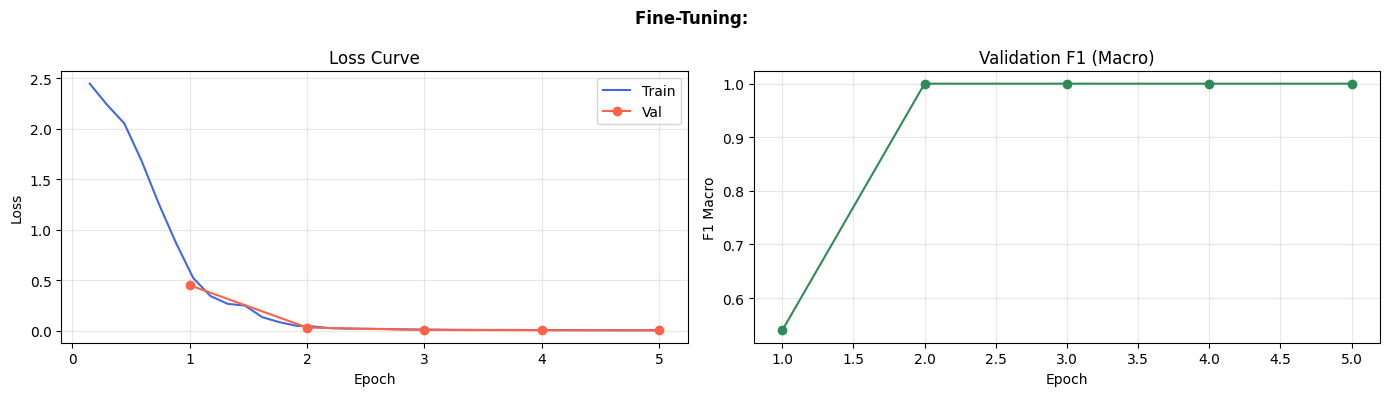

In [206]:
log_history = trainer.state.log_history

train_logs = [(e['epoch'], e['loss']) for e in log_history if 'loss' in e]
eval_logs  = [(e['epoch'], e['eval_loss']) for e in log_history if 'eval_loss' in e]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(*zip(*train_logs), label='Train', color='royalblue')
axes[0].plot(*zip(*eval_logs),  label='Val',   color='tomato', marker='o')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Val F1
f1_logs = [(e['epoch'], e['eval_f1_macro']) for e in log_history if 'eval_f1_macro' in e]
axes[1].plot(*zip(*f1_logs), color='seagreen', marker='o')
axes[1].set_title('Validation F1 (Macro)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Macro')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Fine-Tuning: ', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150)
plt.show()

## Step 13 — Evaluation on Validation Set

In [207]:
val_metrics = trainer.evaluate(val_dataset)
print('=== Validation Set Metrics ===')
for k, v in val_metrics.items():
    if isinstance(v, float):
        print(f'  {k:<30}: {v:.4f}')

=== Validation Set Metrics ===
  eval_loss                     : 0.0308
  eval_accuracy                 : 1.0000
  eval_f1_macro                 : 1.0000
  eval_f1_weighted              : 1.0000
  eval_runtime                  : 2.4983
  eval_samples_per_second       : 124.0850
  eval_steps_per_second         : 4.0030
  epoch                         : 5.0000


## Step 14 — Evaluation on Test Set

In [208]:
test_preds_output = trainer.predict(test_dataset)
test_preds        = np.argmax(test_preds_output.predictions, axis=-1)
test_labels       = test_preds_output.label_ids

acc  = accuracy_score(test_labels, test_preds)
f1m  = f1_score(test_labels, test_preds, average='macro')
f1w  = f1_score(test_labels, test_preds, average='weighted')

print('=== Test Set Metrics ===')
print(f'  Accuracy        : {acc:.4f}')
print(f'  F1 Macro        : {f1m:.4f}')
print(f'  F1 Weighted     : {f1w:.4f}')

=== Test Set Metrics ===
  Accuracy        : 1.0000
  F1 Macro        : 1.0000
  F1 Weighted     : 1.0000


## Step 15 — Full Classification Report

In [209]:
label_names = [ID2LABEL[i] for i in range(NUM_LABELS)]

report = classification_report(
    test_labels,
    test_preds,
    target_names=label_names,
    digits=4,
)
print(report)

# Save report to file
with open(f'{OUTPUT_DIR}/classification_report.txt', 'w') as f:
    f.write(report)

                            precision    recall  f1-score   support

   Balanced NPK Fertilizer     1.0000    1.0000    1.0000        31
                   Compost     1.0000    1.0000    1.0000        75
                       DAP     1.0000    1.0000    1.0000       211
General Purpose Fertilizer     1.0000    1.0000    1.0000         6
                    Gypsum     1.0000    1.0000    1.0000        11
                      Lime     1.0000    1.0000    1.0000        36
         Muriate of Potash     1.0000    1.0000    1.0000        65
        Organic Fertilizer     1.0000    1.0000    1.0000        19
                      Urea     1.0000    1.0000    1.0000        31
Water Retaining Fertilizer     1.0000    1.0000    1.0000       135

                  accuracy                         1.0000       620
                 macro avg     1.0000    1.0000    1.0000       620
              weighted avg     1.0000    1.0000    1.0000       620



## Step 16 — Confusion Matrix

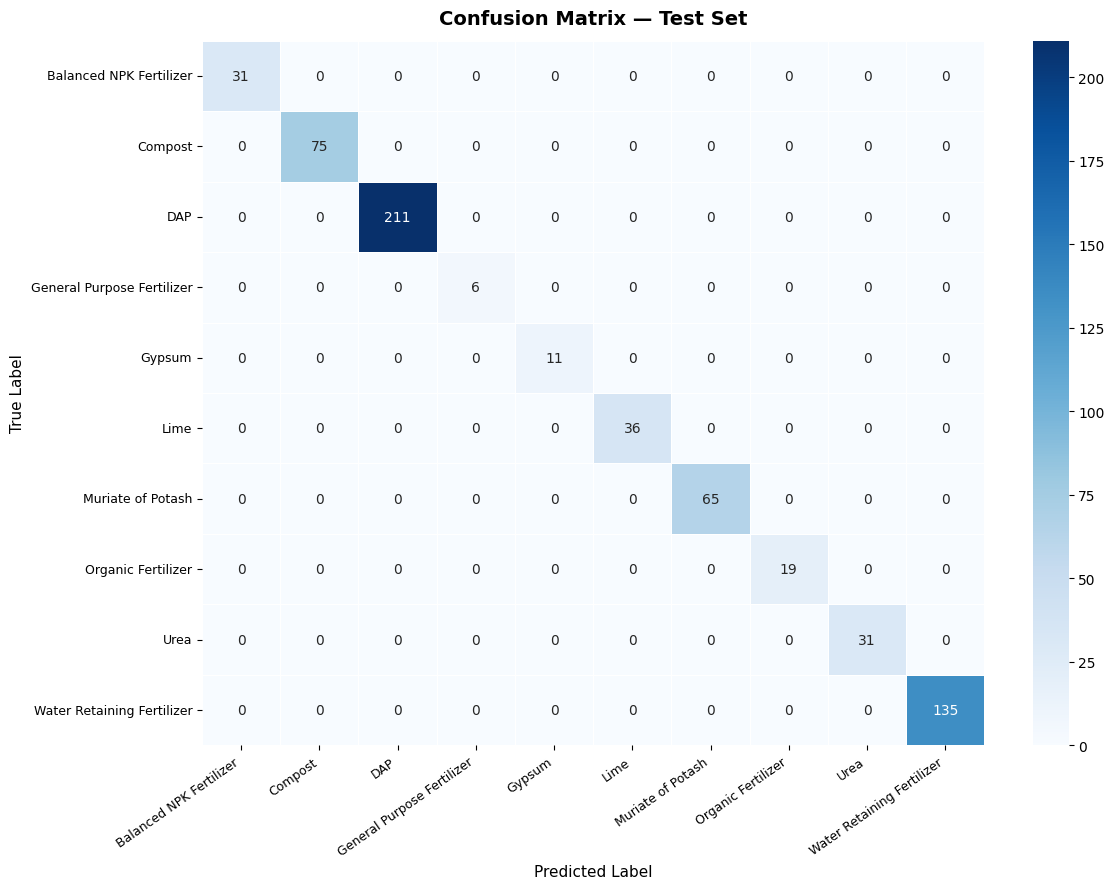

In [210]:
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label',      fontsize=11)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150)
plt.show()

## Step 17 — Per-Class F1 Bar Chart

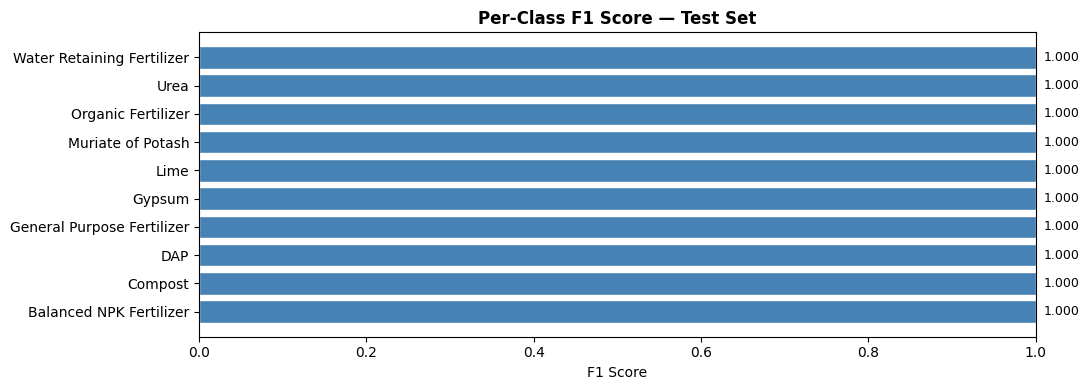

In [211]:
per_class_f1 = f1_score(test_labels, test_preds, average=None)

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.barh(label_names, per_class_f1, color='steelblue', edgecolor='white')
ax.set_xlim(0, 1.0)
ax.set_xlabel('F1 Score')
ax.set_title('Per-Class F1 Score — Test Set', fontweight='bold')
for bar, val in zip(bars, per_class_f1):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/per_class_f1.png', dpi=150)
plt.show()

## Step 18 — Inference on New Samples

In [212]:
def predict_fertilizer(text: str, model, tokenizer, device, id2label: dict) -> dict:
    """
    Run inference on a single text string.
    Returns predicted label, confidence, and full probability distribution.
    """
    model.eval()
    encoding = tokenizer(
        text,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    ).to(device)

    with torch.no_grad():
        logits = model(**encoding).logits

    probs  = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
    pred_id = int(np.argmax(probs))

    return {
        'predicted_label': id2label[pred_id],
        'predicted_id'   : pred_id,
        'confidence'     : float(probs[pred_id]),
        'probabilities'  : {id2label[i]: float(probs[i]) for i in range(len(probs))},
    }


# ── Test on 3 held-out samples ───────────────────────────────────────────────
for i in range(3):
    row     = test_df.iloc[i]
    result  = predict_fertilizer(row['text'], model, tokenizer, DEVICE, ID2LABEL)
    true_lbl = ID2LABEL[row['label']]

    status = '✓' if result['predicted_label'] == true_lbl else '✗'
    print(f'\n[Sample {i+1}] {status}')
    print(f'  True      : {true_lbl}')
    print(f'  Predicted : {result["predicted_label"]}  (conf: {result["confidence"]:.3f})')
    print(f'  Text      : {row["text"][:120]}...')


[Sample 1] ✓
  True      : DAP
  Predicted : DAP  (conf: 0.995)
  Text      : In this condition, the temperature is 29.48754867°C, soil moisture is 0.445904543%, rainfall is -85.70959335 mm, soil pH...

[Sample 2] ✓
  True      : Urea
  Predicted : Urea  (conf: 0.965)
  Text      : In this condition, the temperature is 40.81466924°C, soil moisture is 0.496954306%, rainfall is 306.0816006 mm, soil pH ...

[Sample 3] ✓
  True      : DAP
  Predicted : DAP  (conf: 0.995)
  Text      : In this condition, the temperature is 30.48387894°C, soil moisture is 0.714933302%, rainfall is 55.41611672 mm, soil pH ...


## Step 19 — Save Fine-Tuned Model & Tokenizer

In [213]:
SAVE_DIR = f'{OUTPUT_DIR}/final_model'

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f'Model saved to: {SAVE_DIR}')
print('Files:', os.listdir(SAVE_DIR))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /kaggle/working/agbert_fertilizer/final_model
Files: ['tokenizer_config.json', 'model.safetensors', 'tokenizer.json', 'config.json']


## Step 20 — Reload & Verify Saved Model

In [214]:
loaded_tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
loaded_model     = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(DEVICE)

# Quick smoke test
sample_text = test_df.iloc[0]['text']
result = predict_fertilizer(sample_text, loaded_model, loaded_tokenizer, DEVICE, ID2LABEL)
print('Loaded model inference test:')
print(f"  Prediction : {result['predicted_label']}  (conf: {result['confidence']:.4f})")
print('\nReloaded model works correctly ✓')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded model inference test:
  Prediction : DAP  (conf: 0.9946)

Reloaded model works correctly ✓


---
## Summary

| Step | Detail |
|------|--------|
| Base model | `recobo/agriculture-bert-uncased` |
| Classification head | 10-class linear layer (replaces MLM head) |
| Max sequence length | 256 tokens |
| Batch size | 32 (train) / 64 (eval) |
| Learning rate | 2e-5 with cosine scheduler |
| Mixed precision | FP16 (P100) |
| Early stopping | Patience = 3 (monitoring val F1 macro) |
| Split | 70 / 15 / 15 stratified |